In [33]:
import pandas as pd
import numpy as np
from math import radians, cos, sin, asin, sqrt
from datetime import timedelta
from datetime import date, timedelta,datetime as dt
import numpy as np
import h3
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer

def import_data(file_name):
    data = pd.read_csv(file_name)
    return data


def haversine(lon1, lat1, lon2, lat2):
    """
    Distancia en kilómetros entre
    dos puntos en la superficie de la Tierra
    """
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    b = cos(lat1) * cos(lat2) * sin(dlon/2)**2
    a = sin(dlat/2)**2 + b
    c = 2 * asin(sqrt(a))
    r = 6371
    return c * r



def gen_dist_matrix(locations):

    dist_matrix = []
    tot_locations = len(locations)

    #Cuidado, este loop no está optimizado

    for i in locations.index:
        for j in locations.index:
            locd = locations.loc[i]
            loco = locations.loc[j]
            distance = haversine(locd['lon'], locd['lat'], loco['lon'], loco['lat'])
            dist_matrix.append([i,j,distance])
    dist_df = pd.DataFrame(dist_matrix, columns=['loc1', 'loc2', 'distance'])
    return dist_df


def cluster_generator(locations, treshold_distance):

    """
    Genera clusters de lugares cercanos dadas las ubicaciones de
    recolección y entrega
    """

    dist_df = gen_dist_matrix(locations)

    clusters = dist_df[(dist_df['distance']<treshold_distance)].copy()
    clusters = clusters[clusters['loc1']!=clusters['loc2']].copy()
    clusters = clusters.sort_values(by='loc1')

    cluster_dict = {}

    for i in clusters['loc1'].values:
        neigh = clusters[clusters['loc1']==i]['loc2'].values
        filter_arr = neigh > i
        neigh_add = neigh[filter_arr]
        if len(neigh_add) > 0:
            mother = np.max(neigh_add)
            for j in neigh_add:
                if j not in cluster_dict.keys():
                    cluster_dict[i] = mother
    return cluster_dict


Just commenting most of the prior processing data and importing at the saved point to save a little bit of time. 

In [2]:
# data_routes = pd.read_csv(folder_data + 'transport_routes.csv')
# data_routes_stops = pd.read_csv(folder_data + 'transport_route_stops.csv')
# address = pd.read_csv(folder_data + 'addresses.csv')
# print("Loaded!")
# data_routes_stops = data_routes_stops.join(address[['lat', 'lon', 'id', 'name']].set_index('id'), on='address_id')
# data_routes_stops[['lat', 'lon']] = data_routes_stops[['lat', 'lon']].map(float)

# # Cleaning datetime vars

# datetime_vars = ['schedule_arrival',
#                  'schedule_departure',
#                  'external_schedule_arrival',
#                  'external_schedule_departure',
#                  'real_arrival',
#                  'real_departure']
# data_routes_stops[datetime_vars] = data_routes_stops[datetime_vars].map(lambda x: pd.to_datetime(x, errors='coerce'))




In [3]:
# # Store clustering

# locations = address[['id', 'lat', 'lon']].drop_duplicates().copy()
# locations = locations.dropna()
# clusters = cluster_generator(locations, 0.1)
# locations['id2'] = locations['id'].apply(lambda x: clusters.get(x, x))


# duplic_dict = dict()

# for i in range(len(locations['id'].values)):
#     dd = locations.iloc[i]
#     rr = data_routes_stops[(data_routes_stops['lat']==dd['lat']) & (data_routes_stops['lon']==dd['lon'])]
#     for idx in rr['address_id'].values:
#         duplic_dict[idx] = dd['id2']

# data_routes_stops['location_id'] = data_routes_stops['address_id'].apply(lambda x: duplic_dict.get(x, np.nan))

In [4]:
# # Correcting trip order

# all_trips_info = []
# trip_id = list(data_routes_stops['transport_route_id'].unique())
# for trip in trip_id:
#     info_viaje = data_routes_stops[data_routes_stops['transport_route_id']==trip].sort_values(by='real_departure').copy()
#     total_stops = len(info_viaje)
#     info_viaje['real_seq'] = list(range(1, total_stops+1))
#     for i in range(total_stops-1):

#         list_origin = info_viaje.iloc[i][['transport_route_id',
#                                           'lat',
#                                           'lon',
#                                           'location_id',
#                                           'real_departure',
#                                           'external_schedule_departure',
#                                           'real_seq'
#                                          ]]
        
#         list_dest = info_viaje.iloc[i+1][['lat',
#                                           'lon',
#                                           'location_id',
#                                           'real_arrival',
#                                           'external_schedule_arrival'
#                                         ]]
    
#         try:
#             eta = [info_viaje.iloc[i+1]['schedule_arrival']]
#         except:
#             eta = [pd.to_datetime('NaT')]
    
#         final_list = list(list_origin) + list(list_dest) + eta
    
#         all_trips_info.append(final_list)


In [5]:
# # Trip times calculations

# columns_trips = ['external_id',
#                  'lat_origin',
#                  'lon_origin',
#                  'location_id_origin',
#                  'real_departure_origin',
#                  'external_schedule_departure_origin',
#                  'real_seq',
#                  'lat_dest',
#                  'lon_dest',
#                  'location_id_dest',
#                  'real_arrival_dest',
#                  'external_schedule_arrival_dest',
#                  'eta_arrival_dest'
#                 ]

# data_trips = pd.DataFrame(all_trips_info, columns=columns_trips)
# data_trips['real_trip_time'] = data_trips['real_arrival_dest'] - data_trips['real_departure_origin']
# data_trips['estimated_trip_time'] = data_trips['eta_arrival_dest'] - data_trips['real_departure_origin']
# data_trips['real_trip_time_minutes'] = data_trips['real_trip_time'].apply(lambda x: x.total_seconds()/60)
# data_trips['estimated_trip_time_minutes'] = data_trips['estimated_trip_time'].apply(lambda x: x.total_seconds()/60)
# data_trips['trip_id'] = data_trips.apply(lambda x: str(x['location_id_origin']) + '-' + str(x['location_id_dest']), axis=1)

# # Save file
# data_trips.to_csv('data_etas.csv', index=False)

We retake the process where it was left 

In [6]:
# Load file
data_trips = import_data('data_etas.csv')

In [7]:
# Just sheer curiosity 
len(data_trips)

586164

In [8]:
# Generating group metrics
# Just prior dropping of NA values in order to make things more sane 
data_trips=data_trips.dropna(subset=['real_departure_origin','estimated_trip_time_minutes',
    'real_trip_time_minutes','real_arrival_dest']).reset_index(drop=True)
data_trips["real_departure_origin"] = pd.to_datetime(data_trips["real_departure_origin"], utc=True)
data_trips["real_arrival_dest"] = pd.to_datetime(data_trips["real_arrival_dest"], utc=True)
data_trips["eta_arrival_dest"] = pd.to_datetime(data_trips["eta_arrival_dest"], utc=True)
# data_trips["external_schedule_arrival_dest"] = pd.to_datetime(data_trips["external_schedule_arrival_dest"], utc=True)


# Keep just valid travel times
dt = data_trips[(data_trips['estimated_trip_time_minutes']>0) &
            (data_trips['real_trip_time_minutes']>0)
            ].copy()

# Statistics for trip times and outliers deleting
dtok = pd.DataFrame(columns=list(dt.columns))
for trip_id in list(dt['trip_id'].unique()):
    total_trips = dt[dt['trip_id']==trip_id].copy()
    if len(total_trips)>=10:
        real_mean = total_trips['real_trip_time_minutes'].mean()
        real_std = total_trips['real_trip_time_minutes'].std()
        eta_mean = total_trips['estimated_trip_time_minutes'].mean()
        eta_std = total_trips['estimated_trip_time_minutes'].std()
        real_metric_up = real_mean + 3.5 * real_std
        real_metric_down = real_mean - 3.5 * real_std
        eta_metric_up = eta_mean + 3.5 * eta_std
        eta_metric_down = eta_mean - 3.5 * eta_std
        tt = total_trips[(total_trips['real_trip_time_minutes'] < real_metric_up) &
                         (total_trips['real_trip_time_minutes'] > real_metric_down)
                         ].copy()
        dtok = pd.concat([dtok, tt])
        continue
        
    elif len(total_trips)>0:
        all_times = total_trips['real_trip_time_minutes']
        real_metric_up = 3 * (min(all_times) + max(all_times))/2
        real_metric_down = 0.25 * (min(all_times) + max(all_times))/2
        tt = total_trips[(total_trips['real_trip_time_minutes'] < real_metric_up) &
                         (total_trips['real_trip_time_minutes'] > real_metric_down) 
                         ].copy()
        dtok = pd.concat([dtok, tt])
        continue

dtok['weekday_departure_origin'] = dtok['real_departure_origin'].apply(lambda x: x.weekday())
dtok['weekday_arrival_dest'] = dtok['real_arrival_dest'].apply(lambda x: x.weekday())
dtok['real_hour_departure_origin'] = dtok['real_departure_origin'].apply(lambda x: int(str(x)[10:13]))
dtok['real_hour_arrival_dest'] = dtok['real_arrival_dest'].apply(lambda x: int(str(x)[10:13]))      
    
dtok['origin_h3_4'] = dtok.apply(lambda x: h3.latlng_to_cell(x['lat_origin'], x['lon_origin'], 4), axis=1)
dtok['origin_h3_5'] = dtok.apply(lambda x: h3.latlng_to_cell(x['lat_origin'], x['lon_origin'], 5), axis=1)
dtok['origin_h3_6'] = dtok.apply(lambda x: h3.latlng_to_cell(x['lat_origin'], x['lon_origin'], 6), axis=1)
dtok['origin_h3_7'] = dtok.apply(lambda x: h3.latlng_to_cell(x['lat_origin'], x['lon_origin'], 7), axis=1)

dtok['dest_h3_4'] = dtok.apply(lambda x: h3.latlng_to_cell(x['lat_dest'], x['lon_dest'], 4), axis=1)
dtok['dest_h3_5'] = dtok.apply(lambda x: h3.latlng_to_cell(x['lat_dest'], x['lon_dest'], 5), axis=1)
dtok['dest_h3_6'] = dtok.apply(lambda x: h3.latlng_to_cell(x['lat_dest'], x['lon_dest'], 6), axis=1)
dtok['dest_h3_7'] = dtok.apply(lambda x: h3.latlng_to_cell(x['lat_dest'], x['lon_dest'], 7), axis=1)
dtok = dtok.drop_duplicates().copy()

/tmp/ipykernel_10313/3190423902.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dtok = pd.concat([dtok, tt])


In [9]:
# just bring in the results from the tc implementation run 
results=pd.read_csv('resultados_ensembles_mult.csv')
results["ds"] = pd.to_datetime(results["ds"], utc=True, errors="coerce")

# a grouped cutoff will let us create a proper validation set to analyze benchmarking
cutoff = results.groupby("unique_id")["ds"].min()   

In [10]:
dtok['prop_real_vs_estimated'] = dtok['real_trip_time_minutes'] / dtok['estimated_trip_time_minutes']

# Second filter
dtok2 = dtok[(dtok['prop_real_vs_estimated']>0.1) & (dtok['prop_real_vs_estimated']<5)].copy()

org_assets = pd.read_csv('org_assets.csv')
transp_route_assets = pd.read_csv('transport_route_assets.csv')
transp_route_assets = transp_route_assets.join(org_assets.set_index('id'), on='org_asset_id')

vars_assets = ['transport_route_id', 'kind']
# These were kept as is. 

# Third filter Stabilization of time series and data flows
# dtok3 = dtok2[(dtok2['real_departure_origin']>='2025-04-01') &
#               (dtok2['real_departure_origin']<='2025-10-01')].copy()
# Validation set
# dtok4 = dtok2[(dtok2['real_departure_origin']>='2025-10-01') &
#               (dtok2['real_departure_origin']<='2025-11-01')].copy()


# We gonna do a different version of this according to the way we just 
# executed on the tc implementation 
dtok2 = dtok2.copy()
dtok2["_cutoff"] = dtok2["trip_id"].map(cutoff)

# dtok4: ONLY ids present in results AND date >= cutoff
dtok4 = dtok2.loc[
    dtok2["_cutoff"].notna()
    & dtok2["real_departure_origin"].notna()
    & (dtok2["real_departure_origin"] >= dtok2["_cutoff"])
].drop(columns="_cutoff")

# dtok3: everything else
# - ids NOT in results (cutoff is NaT) stay here
# - ids in results but date < cutoff also stay here
# date_start and date_end filters were kept bc of possible 
# unknown client logic that isn't currently questioned 
date_start = pd.Timestamp("2025-04-01", tz="UTC")
date_end   = pd.Timestamp("2025-10-01", tz="UTC")
dtok3 = dtok2.loc[
    (
        # ids present in results → before cutoff
        dtok2["_cutoff"].notna() &
        (dtok2["real_departure_origin"] < dtok2["_cutoff"])
    )
    |
    (
        # ids NOT in results → apply manual window filter
        dtok2["_cutoff"].isna() &
        (dtok2["real_departure_origin"] >= date_start) &
        (dtok2["real_departure_origin"] <= date_end)
    )
].drop(columns="_cutoff")

dtok3 = dtok3.join(transp_route_assets[vars_assets].set_index('transport_route_id'),
           on='external_id').copy().drop_duplicates()

dtok4 = dtok4.join(transp_route_assets[vars_assets].set_index('transport_route_id'),
           on='external_id').copy().drop_duplicates()



In [11]:
# vars_model = ['trip_id',
#               'weekday_departure_origin',
#               'real_hour_departure_origin',
#               'estimated_trip_time_minutes',
#               'dest_h3_4',
#               'origin_h3_4',
#               'real_trip_time_minutes',
#               'kind'
#              ]

# prop_sample = 0.8
# X = dtok3[vars_model].copy()
# y = X['real_trip_time_minutes']

In [12]:
# #Start HERE sampling:
# sample_size = int(np.floor(prop_sample*len(X)))
# all_index = list(X.index)
# index_train = random.sample(all_index, k=sample_size)
# index_test = list(set(all_index) - set(index_train))

# #Separate subsamples
# X_train, X_test = X.loc[index_train], X.loc[index_test]
# y_train, y_test = y[index_train], y[index_test]
# X = X.drop(columns=['real_trip_time_minutes'])

# #Statistics for sumbsamples
# mean_times_X_train = X_train.groupby('trip_id').agg({'real_trip_time_minutes':
#                                                      ['mean', 'median', 'count']}).copy()
# mean_times_X_train.columns = mean_times_X_train.columns.droplevel(0)
# X_train = X_train.join(mean_times_X_train, on='trip_id')
# X_train = X_train.drop(columns=['real_trip_time_minutes'])

# mean_times_X_test = X_test.groupby(['trip_id', 'weekday_departure_origin',
#               'real_hour_departure_origin']).agg({'real_trip_time_minutes':
#                                                    ['mean', 'median', 'count']}).copy()
# mean_times_X_test.columns = mean_times_X_test.columns.droplevel(0)
# X_test = X_test.join(mean_times_X_train, on='trip_id')
# X_test = X_test.drop(columns=['real_trip_time_minutes'])

# mean_times_X_test

I found that by cutting most of the proposed variables, the model actually performs better. Time is sort of similar. 
The problem with the way this was being approached was that using one-hot encoding on a very diverse column for like 
for example trip_id will just lead to a huge amount of columns, which will logically lead to a non-efficient 
training process. Keeping just weekday and hour as categorical variable led to a much saner performance. 

In [13]:
# vars_model = ['trip_id',
#               'weekday_departure_origin',
#               'real_hour_departure_origin',
#               'estimated_trip_time_minutes',
#               'dest_h3_4',
#               'dest_h3_5',
#               'dest_h3_6',
#               'origin_h3_4',
#               'origin_h3_5',
#               'origin_h3_6',
#               'real_trip_time_minutes',
#               'kind'
#              ]

vars_model = ['weekday_departure_origin',
              'real_hour_departure_origin',
              'estimated_trip_time_minutes',
              'real_trip_time_minutes',
             ]

In [14]:
# This is kept. 
prop_sample = 0.85

X = dtok3[vars_model].copy().drop_duplicates()
y = X['real_trip_time_minutes']

#Start HERE sampling:
sample_size = int(np.floor(prop_sample*len(X)))
all_index = list(X.index)
index_train = random.sample(all_index, k=sample_size)
index_test = list(set(all_index) - set(index_train))

#Separate subsamples
X_train, X_test = X.loc[index_train], X.loc[index_test]
y_train, y_test = y[index_train], y[index_test]
X = X.drop(columns=['real_trip_time_minutes'])


#Statistics for sumbsamples
# uncomment trip_id if you are approaching aleph's full variable set
vars_join = [
            # 'trip_id',
             'weekday_departure_origin',
             'real_hour_departure_origin']

mean_times_X_train = X_train.groupby(vars_join).agg({'real_trip_time_minutes':
                                                     ['mean', 'median', 'count']}).copy()
mean_times_X_train.columns = mean_times_X_train.columns.droplevel(0)
X_train = X_train.join(mean_times_X_train, on=vars_join)
X_train = X_train.drop(columns=['real_trip_time_minutes'])

mean_times_X_test = X_test.groupby(vars_join).agg({'real_trip_time_minutes':
                                                   ['mean', 'median', 'count']}).copy()
mean_times_X_test.columns = mean_times_X_test.columns.droplevel(0)

X_test = X_test.join(mean_times_X_train, on=vars_join)
X_test = X_test.drop(columns=['real_trip_time_minutes'])


categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

'''results
#Do not works good:
categorical_cols = ['trip_id', 
                    'weekday_departure_origin',
                    'real_hour_departure_origin',
                    'dest_h3_4',
                    'origin_h3_4',]

numeric_cols = ['estimated_trip_time_minutes']

'''

# Define the transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# Fit + transform
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

I also added specific parameters on the model in lieu of a couple of objectives:
- limited amount of estimators 
- limited amount of max_depth to avoid this running forever 
- random state for reproducibility

In [15]:
# Random forest Model
# Train classifier
rfr = RandomForestRegressor(
    n_estimators=300,
    n_jobs=-1,
    random_state=0,
    max_depth=20,          # or 16 if you want faster
    min_samples_leaf=10,   # huge runtime + variance control
    max_features="sqrt",   # reduces split search cost
    bootstrap=True
)

# rfr = RandomForestRegressor(
#     n_jobs=-2,
# )
rfr.fit(X_train_enc, y_train)
y_pred = rfr.predict(X_test_enc)

In [16]:
tree = rfr.estimators_[0]
print("depth:", tree.get_depth(), "leaves:", tree.get_n_leaves())
# this is just for diagnosing non smooth trees and making sure this is doing well

depth: 20 leaves: 7900


In [17]:
# R2 Score
print("R2 score:", r2_score(y_test, y_pred))

# RMSE
rmse = mean_squared_error(y_test, y_pred)**0.5
print("RMSE:", rmse)

# Just diagnosing performance on test set 

R2 score: 0.5839328674425259
RMSE: 730.1940400841141


Text(0.5, 1.0, 'Multiplicador de tiempo de Google por viaje')

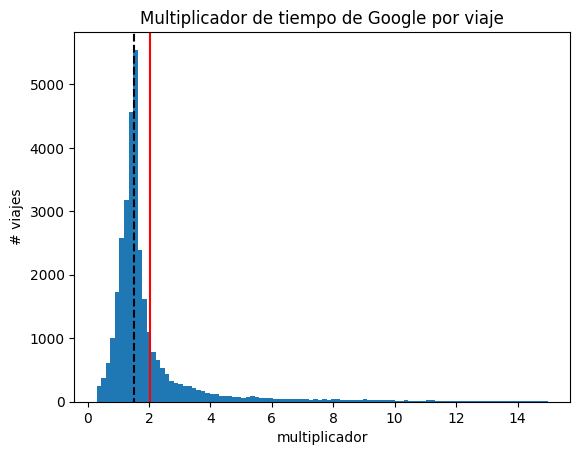

In [18]:
# Compare to Google Maps
# this is kept from aleph things. 
plt.hist((1.5*X_test['estimated_trip_time_minutes']/y_test), bins=100)
plt.axvline(np.mean(1.5*X_test['estimated_trip_time_minutes']/y_test), -0.1, 1000, color='red')
plt.axvline(1.5, -0.1, 1000, color='k', linestyle='dashed')
plt.xlabel('multiplicador')                                                                                                                                                     
plt.ylabel('# viajes')
plt.title('Multiplicador de tiempo de Google por viaje')

Now to the fun part, taking a look at validation set 

In [19]:
# Model on validation
X_validation = dtok4[vars_model].copy()
y_validation = X_validation['real_trip_time_minutes']
X_validation = X_validation.drop(columns=['real_trip_time_minutes'])

X_validation_enc = preprocessor.transform(X_validation)
y_validation_pred = rfr.predict(X_validation_enc)

Text(0, 0.5, 'tiempo previsto \n (minutos)')

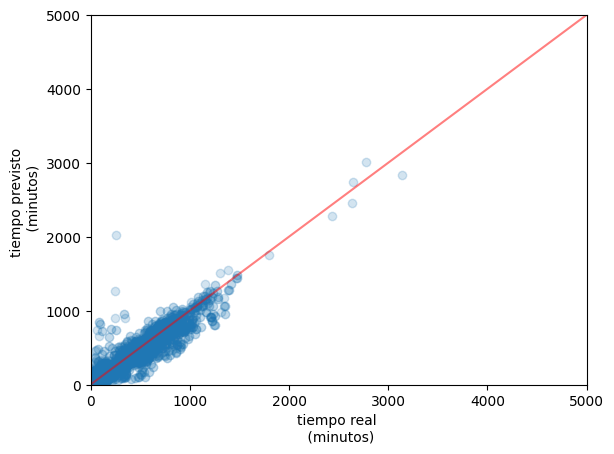

In [20]:
# Prediction over validation
plt.scatter(y_validation, y_validation_pred, alpha=0.1)

xpoints = np.array([0, 100000])
ypoints = np.array([0, 100000])

plt.plot(xpoints, ypoints, color='red', alpha=0.5)
plt.xlim(0,5000)
plt.ylim(0,5000)

plt.xlabel('tiempo real \n (minutos)')
plt.ylabel('tiempo previsto \n (minutos)')

In [21]:
len(X_validation)

13516

In [22]:
len(dtok4.trip_id.unique())

50

In [23]:
# let's just now look at 
results_temp=pd.read_csv('resultados_ensembles_mult.csv')
results_temp["ds"] = pd.to_datetime(results_temp["ds"], utc=True, errors="coerce")
ensembles=['meanensemble','medianensemble','maxensemble','minensemble']
results_temp.columns=['trip_id','real_departure2']+ensembles


Remember to multiply or add depending on the results file used in order to reconstruct the final forecast correctly 

Trips: 50
Share where median ensemble wins: 0.68
Median % improvement: 6.694025718766387
Mean % improvement: 1.115033319750413
Max % improvement: 80.37033452087404


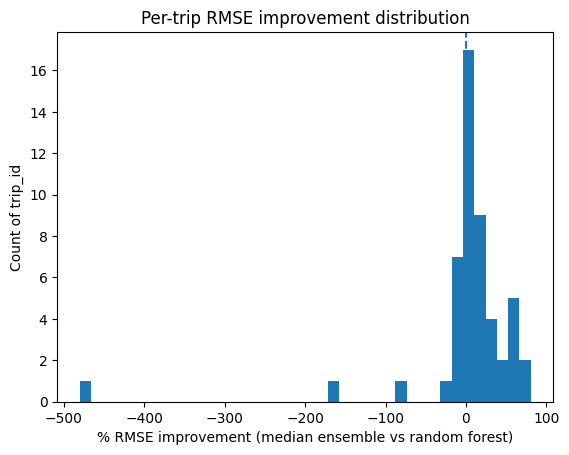

In [32]:
# merging our results with the validation dataset and see what's what
new_guy=dtok4[vars_model+['real_departure_origin',
                           'trip_id','real_trip_time_minutes'
                          ]].copy()
new_guy['random_forest']=y_validation_pred
new_guy.to_csv('procesos_aleph.csv',index=False)

# break off
new_guy['real_departure2']=new_guy["real_departure_origin"].dt.floor("6H")
new_guy=new_guy.merge(results_temp,on=['trip_id','real_departure2'],how='left')
mea_preds=new_guy['meanensemble']*new_guy['estimated_trip_time_minutes']
med_preds=new_guy['medianensemble']*new_guy['estimated_trip_time_minutes']
max_preds=new_guy['maxensemble']*new_guy['estimated_trip_time_minutes']
min_preds=new_guy['minensemble']*new_guy['estimated_trip_time_minutes']
bench=new_guy['estimated_trip_time_minutes']
new_guy["trip_id"] = new_guy["trip_id"].astype(str)
new_guy=new_guy.reset_index(drop=True)

new_guy['median_ensemble']=med_preds


# --- keep only what we need, and guarantee single columns ---
work = new_guy.loc[:, ["trip_id", "real_trip_time_minutes", "random_forest", "median_ensemble"]].copy()
work = work.loc[:, ~work.columns.duplicated()]  # insurance if you somehow have duplicates

# --- force numeric safely, without pd.to_numeric pitfalls ---
for c in ["real_trip_time_minutes", "random_forest", "median_ensemble"]:
    work[c] = pd.Series(work[c]).astype("float64")  # will error loudly if something is truly non-numeric

# --- squared errors ---
work["sq_err_rf"] = (work["real_trip_time_minutes"] - work["random_forest"]) ** 2
work["sq_err_med"] = (work["real_trip_time_minutes"] - work["median_ensemble"]) ** 2

# --- RMSE by trip_id ---
rmse_df = (
    work.groupby("trip_id", sort=False)
        .agg(
            rmse_rf=("sq_err_rf", lambda x: np.sqrt(x.mean())),
            rmse_med=("sq_err_med", lambda x: np.sqrt(x.mean())),
            n=("sq_err_rf", "size"),
        )
        .reset_index()
)

# --- % improvement (positive => median ensemble better) ---
rmse_df["pct_improvement"] = np.where(
    rmse_df["rmse_rf"] == 0,
    np.nan,
    (rmse_df["rmse_rf"] - rmse_df["rmse_med"]) / rmse_df["rmse_rf"] * 100
)

# --- quick summary ---
print("Trips:", len(rmse_df))
print("Share where median ensemble wins:", (rmse_df["pct_improvement"] > 0).mean())
print("Median % improvement:", rmse_df["pct_improvement"].median())
print("Mean % improvement:", rmse_df["pct_improvement"].mean())
print("Max % improvement:", rmse_df["pct_improvement"].max())


# --- histogram ---
vals = rmse_df["pct_improvement"].dropna()
plt.hist(vals, bins=40)
plt.axvline(0, linestyle="--")
plt.xlabel("% RMSE improvement (median ensemble vs random forest)")
plt.ylabel("Count of trip_id")
plt.title("Per-trip RMSE improvement distribution")
plt.show()

In [25]:
rmse_df.describe()

,rmse_rf,rmse_med,n,pct_improvement
count,50.000000,50.000000,50.000000,50.000000
mean,77.998134,66.952548,270.320000,1.115033
std,62.337578,52.630099,289.063614,79.109868
min,2.977961,2.424679,64.000000,-480.288192
25%,22.934134,23.377894,152.500000,-0.713220
50%,64.194291,49.477013,201.000000,6.694026
75%,110.348533,104.033360,241.750000,23.939738
max,259.738599,175.415962,1990.000000,80.370335


In [26]:
# R² score (1 = perfect prediction, 0 = baseline)
print("R2 score of Aleph:", r2_score(y_validation, y_validation_pred))
print("R2 score of mea:", r2_score(y_validation, mea_preds))
print("R2 score of min:", r2_score(y_validation, min_preds))
print("R2 score of max:", r2_score(y_validation, max_preds))
print("R2 score of med:", r2_score(y_validation, med_preds))
print("R2 score of benchmark:", r2_score(y_validation, bench))


# RMSE (root mean squared error)
rmse = mean_squared_error(y_validation, y_validation_pred)**0.5
rmse_mea = mean_squared_error(y_validation, mea_preds)**0.5
rmse_min = mean_squared_error(y_validation, min_preds)**0.5
rmse_max = mean_squared_error(y_validation, max_preds)**0.5
rmse_med = mean_squared_error(y_validation, med_preds)**0.5
rmse_benchmark = mean_squared_error(y_validation, bench)**0.5


print("RMSE of Aleph:", rmse)
print("RMSE of mea:", rmse_mea)
print("RMSE of min:", rmse_min)
print("RMSE of max:", rmse_max)
print("RMSE of med:", rmse_med)
print("RMSE of benchmark:", rmse_benchmark)

R2 score of Aleph: 0.9165539510841899
R2 score of mea: 0.9077879224048229
R2 score of min: 0.7945914227531077
R2 score of max: 0.23227729512881146
R2 score of med: 0.9258394105827679
R2 score of benchmark: 0.9123097707403415
RMSE of Aleph: 81.7355852961902
RMSE of mea: 85.9215674870682
RMSE of min: 128.2382477189345
RMSE of max: 247.91938175254867
RMSE of med: 77.05394423268199
RMSE of benchmark: 83.78839869893298


Text(0, 0.5, 'tiempo previsto \n (minutos)')

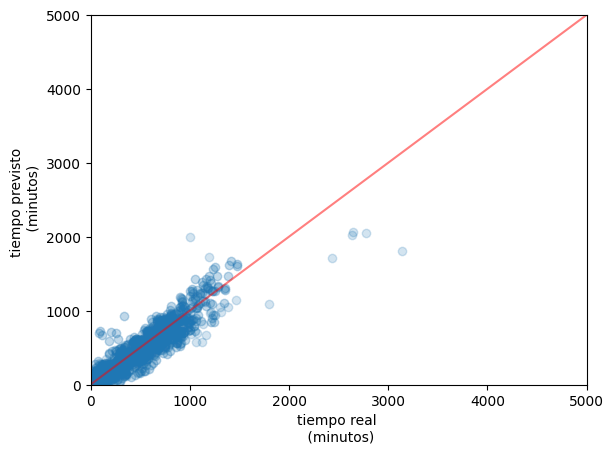

In [27]:
# Prediction over validation

plt.scatter(y_validation, med_preds, alpha=0.1)

xpoints = np.array([0, 100000])
ypoints = np.array([0, 100000])

plt.plot(xpoints, ypoints, color='red', alpha=0.5)
plt.xlim(0,5000)
plt.ylim(0,5000)

plt.xlabel('tiempo real \n (minutos)')
plt.ylabel('tiempo previsto \n (minutos)')

In [28]:
print(y_validation.describe())
print(med_preds.describe())
print(pd.Series(y_validation_pred).describe())


count    13516.000000
mean       185.798226
std        282.959549
min          0.683333
25%         12.795833
50%         41.850000
75%        280.750000
max       3141.383333
Name: real_trip_time_minutes, dtype: float64
count    13516.000000
mean       181.796126
std        277.144663
min          0.237502
25%         10.787190
50%         41.932316
75%        251.901560
max       2057.500154
dtype: float64
count    13516.000000
mean       185.570809
std        268.680149
min          2.833166
25%         17.282737
50%         60.460139
75%        270.069091
max       3005.397184
dtype: float64


In [29]:
# wanna find out how much data is in these fellas. 
results2=pd.read_csv('resultados_ensembles_mult.csv'
)
good_guys=list(set(results['unique_id']))       
count = dtok["trip_id"].isin(good_guys).sum()                                                                                                                                       
print(count/len(dtok))

0.1991443894051664


In [30]:
len(dtok)

341978